# Short-Read (DELLY2)
Here, we aggregate the visualizations of all size classes and depth treatments for linked-read simulations.

In [1]:
library(ggplot2)
library(dplyr)
library(ggpubr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Let's read in the data from the outcomes of the individual size-class assessments and combine them into a single table. Since we'll be comparing this to the long-read data, we should also add a column specifing this is linked-read data and write the entire thing into one file.

In [2]:
lr_inversions <- rbind(
    read.csv("small.sv.assessment", header = T),
    read.csv("medium.sv.assessment", header = T),
    read.csv("large.sv.assessment", header = T),
    read.csv("xl.sv.assessment", header = T)
)
lr_inversions$technology <- "linkedread"
lr_inversions$method <- "delly2"
if(!file.exists("linkedread.sv.assessment")){
    write.csv(lr_inversions, file = "linkedread.sv.assessment", row.names = F, quote = F)
}
head(lr_inversions)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,1,1,0.5,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,delly2
2,2L,1,1,2.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,delly2
3,2L,1,1,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,delly2
4,2L,1,1,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,delly2
5,2L,1,1,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,delly2
6,2L,1,1,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,delly2


### Single-Sample Detection
Let's visualize what detection looked like across all treatments with respect to false/true positive/negative. Here, we facet rows across depths and show all the size treatments across columns.

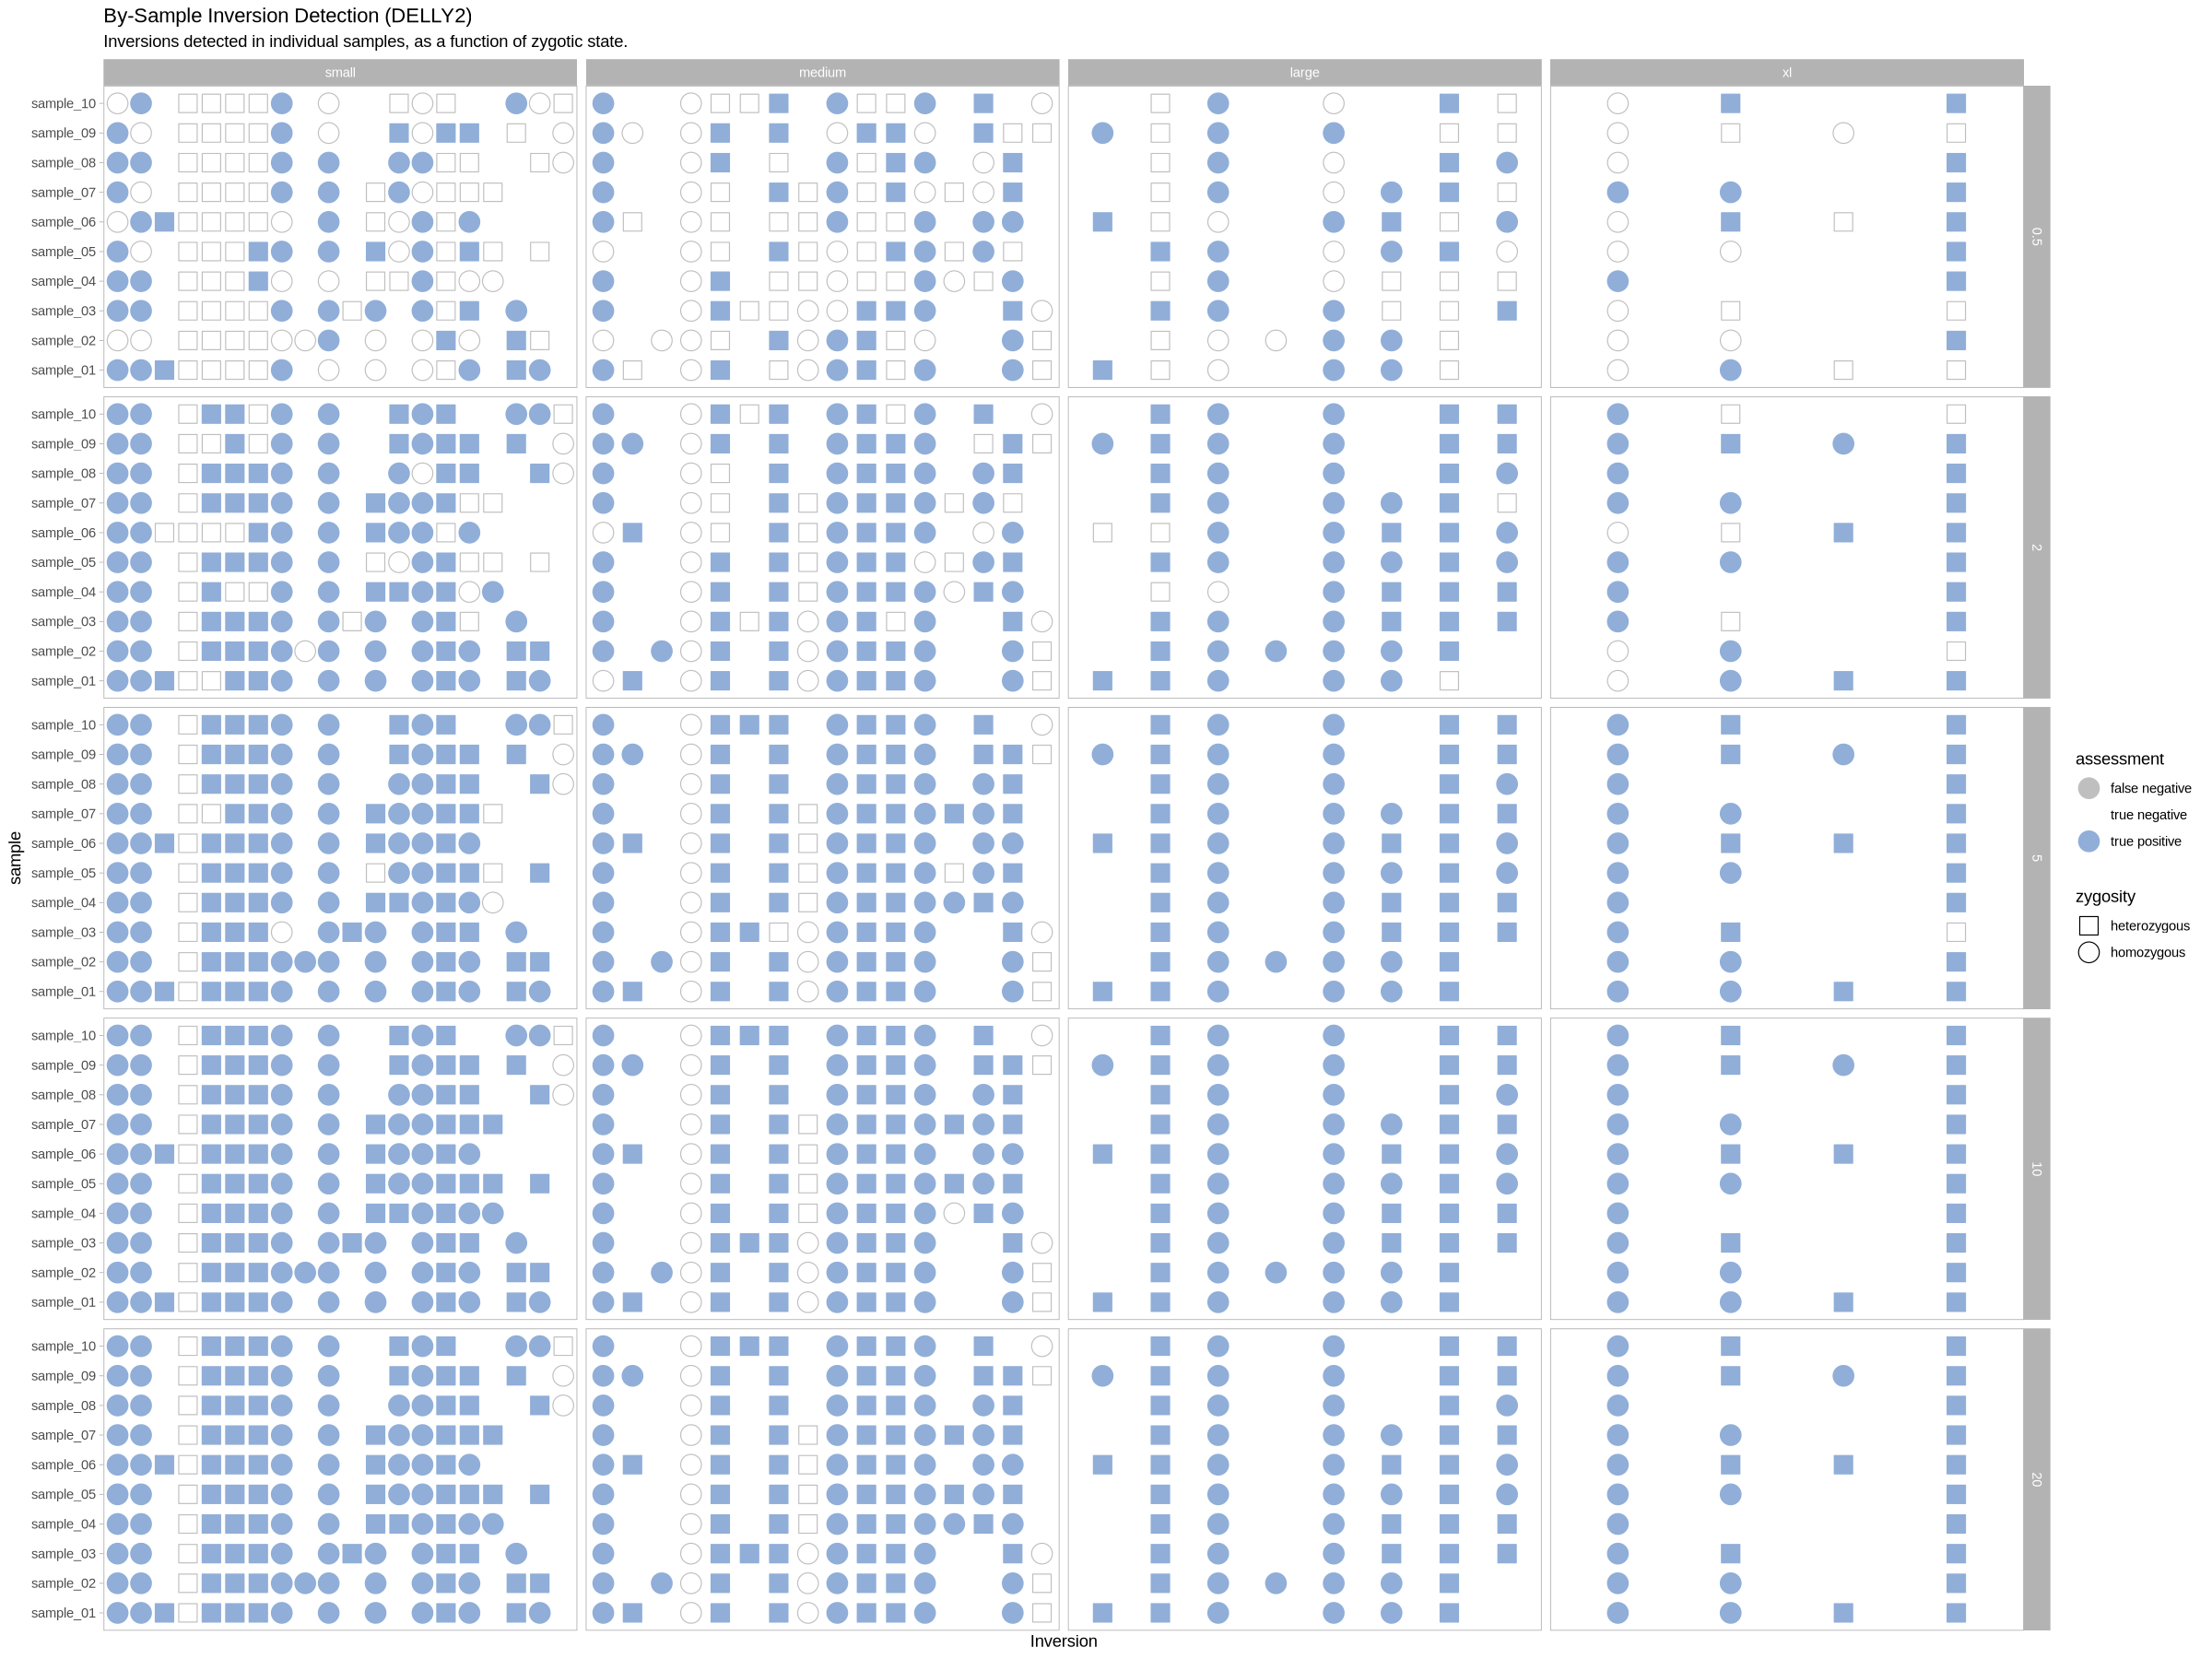

In [3]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 15)
axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
lr_inversions[lr_inversions$sample != 11,] %>%
    ggplot(aes(y = sample, x = id, fill = assessment, color = assessment, shape = zygosity)) +
        geom_point(size = 6) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection (DELLY2)", subtitle = "Inversions detected in individual samples, as a function of zygotic state.") +
        scale_color_manual(values = c("false negative" = "grey75", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_fill_manual(values = c("false negative" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_shape_manual(values = c("homozygous" = 21, "heterozygous" = 22)) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(depth ~ factor(size, levels = c("small", "medium", "large", "xl")), scales = "free_x")
